# Architecture of filters

So, the english is not very good, I will improve that

In [1]:
import itertools

import sympy as sy
import numpy as np

from sympy import Matrix
from scipy.linalg import circulant
from sympy.physics.quantum import TensorProduct
from sympy.matrices.dense import matrix_multiply_elementwise

In [2]:
import fitz

from lib.utils import plot_pdf, plot_pdf2col, symmetrical_cyclic_convolution, conv_circ_fft

In [3]:
from sympy import init_printing
init_printing(use_latex='png', forecolor='White', backcolor='Black')

In [4]:
doc = fitz.open('Blahut_2010_Fast algorithms for signal processing.pdf')

The base for this tutorial is the book "Fast Algorithms or Signal Processing" of Blahut.

This tutorial not work with others vector sizes

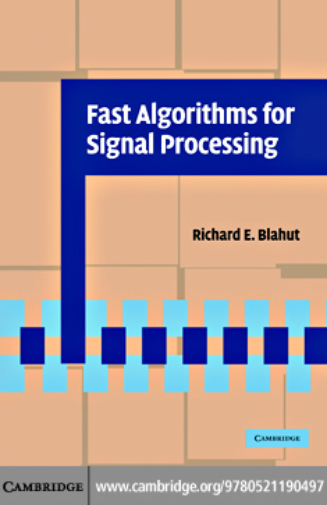

In [5]:
plot_pdf(doc[0], dpi=100)

## Polynomials

Size of vectors

In [6]:
d_num = 3
g_num = 3

In [7]:
b_degree = d_num + g_num - 1
b_degree

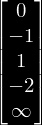

In [8]:
b0 = [0, -1, 1, -2, sy.oo]
# sy.Rational(1, 2)
sy.Matrix(b0)

Example of vectors for the convolution

In [9]:
d_values = list(range(1, d_num+1))
g_values = list(range(1, g_num+1))
print(d_values, g_values)

[1, 2, 3] [1, 2, 3]


Polynomial degree

In [10]:
d_degree = d_num - 1
g_degree = g_num - 1
print(d_degree, g_degree)

2 2


In [11]:
x = sy.symbols("x")
x

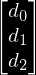

In [12]:
d0 = sy.Matrix(sy.symbols(" ".join(f"d_{i}"for i in range(d_num))))
d0

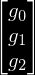

In [13]:
g0 = sy.Matrix(sy.symbols(" ".join(f"g_{i}"for i in range(g_num))))
g0

In [14]:
dx = sum([i*x**e for e, i in enumerate(d0)])
dx

In [15]:
gx = sum([i*x**e for e, i in enumerate(g0)])
gx

In [16]:
sx = gx*dx
sx

In [17]:
xi = [x**i for i in range(1, sy.degree(sx.expand(), x) + 1)]
xi

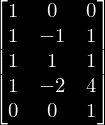

In [18]:
_a_mtx = [[(b **e) for e, d in enumerate(d0)] for b in b0 if b != sy.oo]
_a_inf = [[0] * (len(d0) - 1) + [1]]
a_mtx = sy.Matrix(_a_mtx + _a_inf)
a_mtx

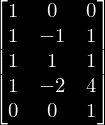

In [19]:
_b_mtx = [[(b **e) for e, d in enumerate(g0)] for b in b0 if b != sy.oo]
_b_inf = [[0] * (len(g0) - 1) + [1]]
b_mtx = sy.Matrix(_b_mtx + _b_inf)
b_mtx

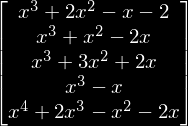

In [20]:
cd = [sy.expand(np.prod([(x - b) for b in i if b != sy.oo])) for i in itertools.combinations(reversed(b0), len(b0)-1)]
sy.Matrix(cd)

In [21]:
b0_inf = [x for x in b0 if x != sy.oo]
b0_inf

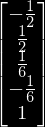

In [22]:
_cq = [
    1/sy.expand(np.prod([(b0 - b) for b in i]))
    for b0, i in 
    zip(b0_inf, itertools.combinations(reversed(b0_inf), len(b0_inf)-1))
]
cq = _cq + [1]
sy.Matrix(cq)

In [23]:
c0 = sy.Matrix([s.subs({x:0}) for s in cd])
c0.T

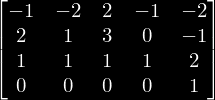

In [24]:
c1 = sy.Matrix([[d.coeff(c, 1) for c in xi] for d in cd])
c1.T

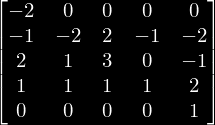

In [25]:
c_mtx = sy.Matrix(c0.T.tolist() + c1.T.tolist())
c_mtx

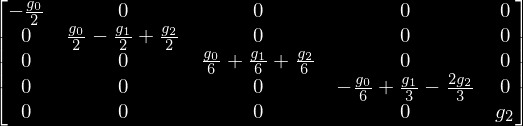

In [26]:
bg_mtx = sy.diag(*(sy.diag(*cq) * b_mtx * g0).tolist())
bg_mtx

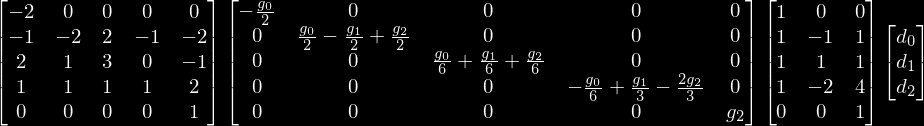

In [27]:
s = sy.MatMul(c_mtx, bg_mtx, a_mtx, sy.Matrix(d0))
s

## Example

In [28]:
subs = {k[0]: v for k, v in zip(d0.tolist()+g0.tolist(), d_values + g_values)}
subs

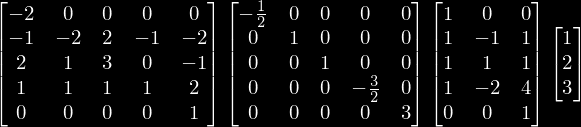

In [29]:
si = s.subs(subs)
si

In [30]:
sy.expand(sx)

Let's compare the output polynomial matrix from direct and winograd method

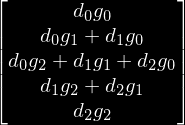

In [31]:
sy.Matrix(np.convolve(np.array(d0).reshape(-1), np.array(g0).reshape(-1)))

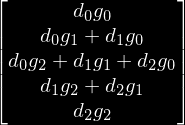

In [32]:
se = sy.MatMul(c_mtx, bg_mtx, a_mtx, sy.Matrix(d0), evaluate=True)
se

Comparing numerical outputs from direct and winograd method

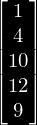

In [33]:
sy.Matrix(np.convolve(d_values, g_values))

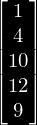

In [34]:
se.subs(subs)

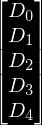

In [44]:
ad0s = Matrix(sy.symbols(" ".join(f"D_{i}"for i in range(len(b0)))))
ad0s

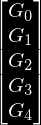

In [36]:
bg0s = Matrix(sy.symbols(" ".join(f"G_{i}"for i in range(len(b0)))))
bg0s

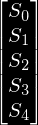

In [37]:
ss0s = Matrix(sy.symbols(" ".join(f"S_{i}"for i in range(len(b0)))))
ss0s

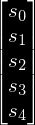

In [38]:
s0s = Matrix(sy.symbols(" ".join(f"s_{i}"for i in range(len(b0)))))
s0s

In [39]:
def step(ff0, mtx, f0):
    f1 = mtx * f0
    f2 = sy.Eq(ff0, sy.Eq(f1, sy.MatMul(mtx, f0, evaluate=False), evaluate=False), evaluate=False)
    return f2

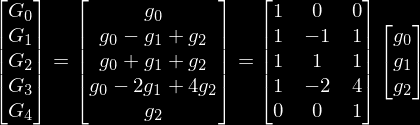

In [40]:
bg1 = step(bg0s, b_mtx, g0)
bg1

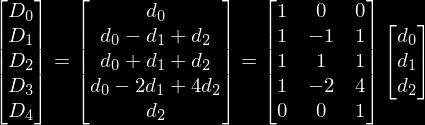

In [41]:
ad1 = step(ad0s, a_mtx, d0)
ad1

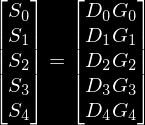

In [45]:
ss1 = sy.Eq(ss0s, sy.diag(*bg0s)*ad0s, evaluate=False)
ss1

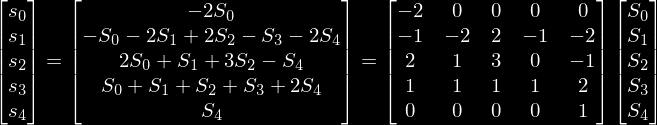

In [43]:
s1 = step(s0s, c_mtx, ss0s)
s1